In [3]:
using ScQubitsMimic
using CairoMakie

_scqubitsmimic_example_dir = normpath(joinpath(dirname(pathof(ScQubitsMimic)), "..", "examples"))
if !isdefined(Main, :ScQubitsMimicExampleMakie)
    include(joinpath(_scqubitsmimic_example_dir, "makie_fontsetup.jl"))
end
ScQubitsMimicExampleMakie.setup_makie_font!()


"Apple SD Gothic Neo"

# Tunable Custom Circuit Analysis

이 노트북은 Yan et al. (2018)의 tunable-coupler 아이디어를 따르는 grounded custom circuit을 `ScQubitsMimic.jl`에서 어떻게 분석할 수 있는지 보여준다.

범위:
- grounded custom circuit 정의
- symbolic Hamiltonian 확인
- variable transformation / mode category 확인
- coupler flux sweep에 따른 low-lying spectrum 변화 관찰

제한:
- full Yan 논문 재현이 아니라 reduced static custom-circuit demo이다.
- `sym_lagrangian`, `plot_potential`, `Circuit` wavefunction plot, `sym_external_fluxes()`, HD symbolic introspection은 현재 repo에서 지원하지 않는다.


## 회로 정의

노드 규약:
- `0`: ground
- `1`: left qubit (`ϕ₁`)
- `2`: coupler (`ϕ_c`)
- `3`: right qubit (`ϕ₂`)

여기서는 실행 가능성과 해상도의 균형을 위해 `ncut=6`을 사용한다.


In [ ]:
tcap_coupled_tmon = """
branches:
  - [JJ, 0, 1, EJ=15.0, EC=0.2]
  - [JJ, 1, 0, EJ=12.0, EC=10.0]
  - [C, 1, 0, EC=0.2]
  - [C, 1, 2, EC=5.0]
  - [JJ, 0, 2, EJ=24.0, EC=10.0]
  - [JJ, 2, 0, EJ=24.0, EC=10.0]
  - [C, 2, 0, EC=0.1]
  - [C, 2, 3, EC=5.0]
  - [JJ, 0, 3, EJ=12.0, EC=10.0]
  - [JJ, 3, 0, EJ=12.0, EC=10.0]
  - [C, 3, 0, EC=0.2]
"""

circ1 = Circuit(tcap_coupled_tmon; ncut=6)


Circuit(SymbolicCircuit(CircuitGraph(Branch[Branch(JJ, 0→1, EJ=12.0, EC=10.0), Branch(JJ, 1→0, EJ=12.0, EC=10.0), Branch(C, 1→0, EC=0.2), Branch(C, 1→2, EC=5.0), Branch(JJ, 0→2, EJ=24.0, EC=10.0), Branch(JJ, 2→0, EJ=24.0, EC=10.0), Branch(C, 2→0, EC=0.1), Branch(C, 2→3, EC=5.0), Branch(JJ, 0→3, EJ=12.0, EC=10.0), Branch(JJ, 3→0, EJ=12.0, EC=10.0), Branch(C, 3→0, EC=0.2)], 3, true), [3, 4, 8], [1, 2, 5, 6, 7, 9, 10, 11], [[(1, 1), (3, 1)], [(2, 1), (3, -1)], [(5, 1), (3, 1), (4, -1)], [(6, 1), (4, 1), (3, -1)], [(7, 1), (4, 1), (3, -1)], [(9, 1), (3, 1), (4, -1), (8, -1)], [(10, 1), (8, 1), (4, 1), (3, -1)], [(11, 1), (8, 1), (4, 1), (3, -1)]], Symbolics.Num[φ₁, φ₂, φ₃], Symbolics.Num[φ̇₁, φ̇₂, φ̇₃], Symbolics.Num[0.675 -0.025 0; -0.025 1.325 -0.025; 0 -0.025 0.675], Symbolics.Num[0 0 0; 0 0 0; 0 0 0], -12.0(cos(Φext₃ - φ₃) + cos(φ₁) + cos(Φext₁ - φ₁) + cos(φ₃)) - 24.0(cos(φ₂) + cos(Φext₂ - φ₂)) + 2.9650364150014252(n₁^2 + n₃^2) + 0.11196641007697691n₁*n₂ + 0.00414690407692507n₁*n₃ + 1.

## 회로 진단

현재 구현에서는 superconducting loop마다 하나의 external flux를 두고, 그 flux를 branch-level allocation을 통해 JJ/L 항에 반영한다.


In [5]:
println("Mode categories: ", circ1.var_categories)
println("External flux variables: ", external_fluxes(circ1))
println("Branch flux allocations: ", circ1.symbolic_circuit.branch_flux_allocations)
println("First 4 eigenvalues: ", eigenvals(circ1; evals_count=4))


Mode categories: VarCategories(periodic=[1, 2, 3], extended=Int64[], free=Int64[], frozen=Int64[])
External flux variables: Symbolics.Num[Φext₁, Φext₂, Φext₃]
Branch flux allocations: Symbolics.Num[0, Φext₁, 0, 0, 0, Φext₂, 0, 0, 0, Φext₃, 0]
First 4 eigenvalues: [-78.52818098408285, -67.46875511541491, -67.39891876935526, -66.79414278766758]


## Symbolic analysis

node basis와 transformed mode basis에서 symbolic Hamiltonian을 확인한다.


In [6]:
H_node = sym_hamiltonian_node(circ1)
H_mode = sym_hamiltonian(circ1)
T, vc = variable_transformation(circ1)

println("Node-basis Hamiltonian:")
println(H_node)
println()
println("Mode-basis Hamiltonian:")
println(H_mode)
println()
println("Transformation matrix T =")
display(T)
println("VarCategories = ", vc)


Node-basis Hamiltonian:
-12.0(cos(Φext₃ - φ₃) + cos(φ₁) + cos(Φext₁ - φ₁) + cos(φ₃)) - 24.0(cos(φ₂) + cos(Φext₂ - φ₂)) + 2.9650364150014252(n₁^2 + n₃^2) + 0.11196641007697691n₁*n₂ + 0.00414690407692507n₁*n₃ + 1.5115465360391884(n₂^2) + 0.11196641007697691n₂*n₃

Mode-basis Hamiltonian:
-24.0(cos(θ₂) + cos(Φext₂ - θ₂)) - 12.0(cos(θ₃) + cos(θ₁) + cos(Φext₃ - θ₃) + cos(Φext₁ - θ₁)) + 2.9650364150014252(nθ₁^2 + nθ₃^2) + 0.11196641007697691(nθ₁ + nθ₃)*nθ₂ + 0.00414690407692507nθ₁*nθ₃ + 1.5115465360391884(nθ₂^2)

Transformation matrix T =
VarCategories = VarCategories(periodic=[1, 2, 3], extended=Int64[], free=Int64[], frozen=Int64[])


3×3 Matrix{Float64}:
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0

## 초기 스펙트럼

낮은 에너지 준위와 전이주파수를 간단히 확인한다.


In [7]:
evals0 = eigenvals(circ1; evals_count=4)
transitions0 = (
    ω01 = evals0[2] - evals0[1],
    ω12 = evals0[3] - evals0[2],
    ω23 = evals0[4] - evals0[3],
)

println("Eigenvalues: ", evals0)
println("Transitions: ", transitions0)


Eigenvalues: [-78.52818098408285, -67.46875511541491, -67.39891876935526, -66.79414278766758]
Transitions: (ω01 = 11.059425868667944, ω12 = 0.0698363460596454, ω23 = 0.6047759816876805)


## Coupler flux sweep

qubit loop flux는 `0.0`으로 고정하고 coupler loop만 sweep한다.

주의:
- 현재 `get_spectrum_vs_paramvals(circ, Symbol("Φext_2"), ...)`는 indexed flux name parsing 문제로 바로 쓰지 않는다.
- 따라서 여기서는 수동 loop로 spectrum을 계산한다.


In [8]:
φc_vals = range(0.0, π; length=21)
levels = Matrix{Float64}(undef, length(φc_vals), 4)
transitions = Matrix{Float64}(undef, length(φc_vals), 3)

for (idx, φc) in enumerate(φc_vals)
    set_external_flux!(circ1, 1, 0.0)
    set_external_flux!(circ1, 2, φc)
    set_external_flux!(circ1, 3, 0.0)

    evals = eigenvals(circ1; evals_count=4)
    levels[idx, :] .= evals
    transitions[idx, 1] = evals[2] - evals[1]
    transitions[idx, 2] = evals[3] - evals[2]
    transitions[idx, 3] = evals[4] - evals[3]
end

relative_levels = levels .- levels[:, 1]
println("Computed ", length(φc_vals), " sweep points.")
println("First relative spectrum row: ", relative_levels[1, :])


Computed 21 sweep points.
First relative spectrum row: [0.0, 11.059425868667944, 11.12926221472759, 11.73403819641527]


## Spectrum plots

아래 그림은 coupler flux에 따른 low-lying levels와 transition frequencies를 보여준다.


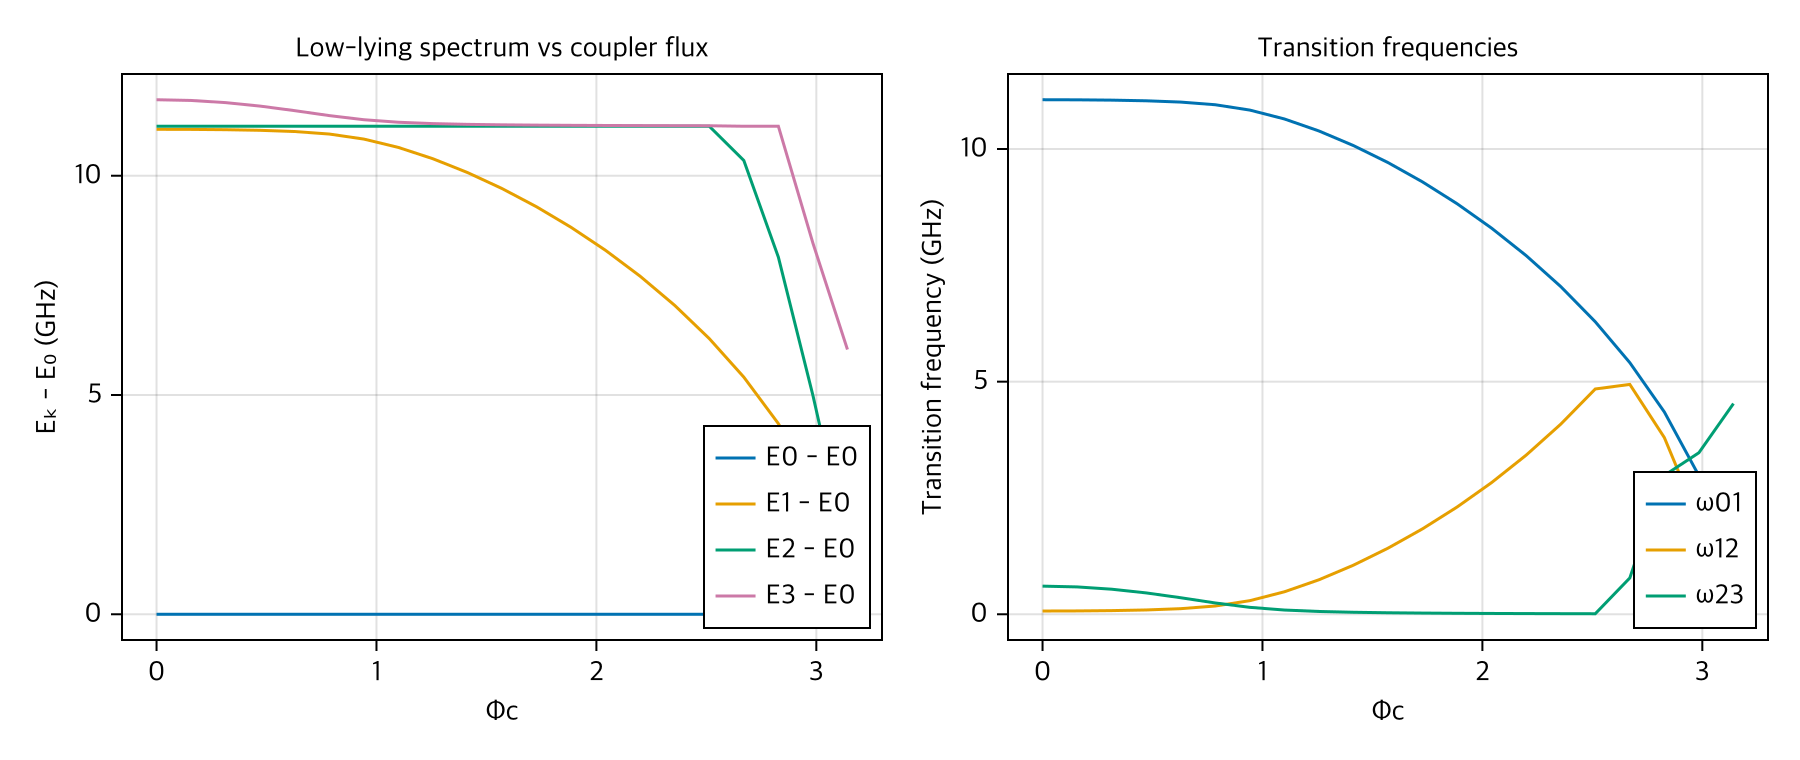

In [9]:
fig = Figure(size=(900, 380))
ax1 = Axis(fig[1, 1],
    xlabel="Φc",
    ylabel="Eₖ - E₀ (GHz)",
    title="Low-lying spectrum vs coupler flux")

for k in 1:size(relative_levels, 2)
    lines!(ax1, φc_vals, relative_levels[:, k], label="E$(k-1) - E0")
end
axislegend(ax1, position=:rb)

ax2 = Axis(fig[1, 2],
    xlabel="Φc",
    ylabel="Transition frequency (GHz)",
    title="Transition frequencies")
lines!(ax2, φc_vals, transitions[:, 1], label="ω01")
lines!(ax2, φc_vals, transitions[:, 2], label="ω12")
lines!(ax2, φc_vals, transitions[:, 3], label="ω23")
axislegend(ax2, position=:rb)

fig


## 제한 사항

이 notebook은 `scqubits`의 `demo_customcircuit.ipynb`와 같은 폭의 기능 전체를 재현하지 않는다.

현재 notebook에서 다루지 않는 항목:
- symbolic Lagrangian
- potential plot
- `Circuit` wavefunction plot
- `sym_external_fluxes()` 같은 loop-to-flux introspection helper
- `configure(...)` 기반 hierarchical diagonalization walkthrough
- indexed flux name (`Φext_2`)를 직접 받는 `get_spectrum_vs_paramvals` 경로
